# Lab 4: Linear Regression

***
- **FIRST name**: Moffat
- **LAST name**: Muriithi
- **Student ID**:

Leave blank if individual:
- **Collaborator names**:
- **Collaborator student IDs**:
***

In today's lab, you will learn:

1.   The process of making predictions;
2.   linear regression.

For this lab, you'll need the dataset `family_heights.csv`.

### Instructions

- **Collaboration**: You must submit your own work. The collaboration policy for the labs is Consultation Collaboration. You may verbally discuss concepts with your classmates, without exchanging written text, code, or detailed advice. You must develop your own solution and submit your own work. All sources of information used including books, websites, students you talked to, must be cited in the submission. Please see the course FAQ document for details on this collaboration policy. We will adhere to current Faculty of Science guidelines on dealing with suspected cases of plagiarism.
- **Software**: We highly recommend that students use Syzygy for completing labs and assignments. This is the software used by the TAs in the course, and we can guarantee that there will be no issues with incompatible environments or imports.
- **Filling out the Notebook**: You must use this notebook to complete your lab. You will execute the questions in the notebook. The questions might ask for a short answer in text form or for you to write and execute a piece of code. Make sure you enter your answer in either case only in the cell provided.
- **Important**:  Do not use a different cell, do not delete cells, and do not create a new cell. Creating new cells for your code is not compatible with the auto-grading system we are using and thus your assignment will not get grading properly and you will lose marks for that question. As a reminder you must remove the raise NotImplementedError() statements from each question when answering.
- **Rules for Datasets**: Any datasets used in the lab cannot be imported from cloud storage, e.g google drive, and must be read from a file either on your local computer or uploaded to the google colab notebook. Importing from cloud storage will result in a zero.
- **Submission Formatting**: When you are done, you will submit your work from the notebook. Make sure to save your notebook before running it, and then submit on Canvas the notebook file with your work completed. Name your file with an L followed by the lab number (ex: L5.ipynb). Failure to do so will result in a zero! Finally your name must be written at the top of the lab or assignment document.


In [1]:
#run this cell
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Predictions

Predictions are an important part of data science because they allow us to make educated guesses based on incomplete data. These guesses are usually in the form of continuous or categorical values. The primary goal of building a predictive model is to make accurate and reliable forecasts based on historical data.

**Question 1.1.** Load the dataset `family_heights.csv` and assign it to the name `heights`. This dataset contains data on the midparent height and child’s height (all in inches) for a population of 934 adult “children”. The midparent height is a weighted average of the heights of the two parents.

In [2]:
# YOUR CODE HERE
heights = pd.read_csv('family_heights.csv')
heights

,family,father,mother,midparentHeight,children,childNum,sex,childHeight
0,1,78.5,67.0,75.43,4,1,male,73.2
1,1,78.5,67.0,75.43,4,2,female,69.2
2,1,78.5,67.0,75.43,4,3,female,69.0
3,1,78.5,67.0,75.43,4,4,female,69.0
4,2,75.5,66.5,73.66,4,1,male,73.5
...,...,...,...,...,...,...,...,...
929,203,62.0,66.0,66.64,3,1,male,64.0
930,203,62.0,66.0,66.64,3,2,female,62.0
931,203,62.0,66.0,66.64,3,3,female,61.0
932,204,62.5,63.0,65.27,2,1,male,66.5


In [3]:
# TEST CELL: do not delete!

**Question 1.2.** Use matplot's `scatter` function to make a scatter plot where `midparentHeight` is the x-axis and `childHeight` is the y-axis. Make sure to include the appropriate labels!

<function matplotlib.pyplot.show(close=None, block=None)>

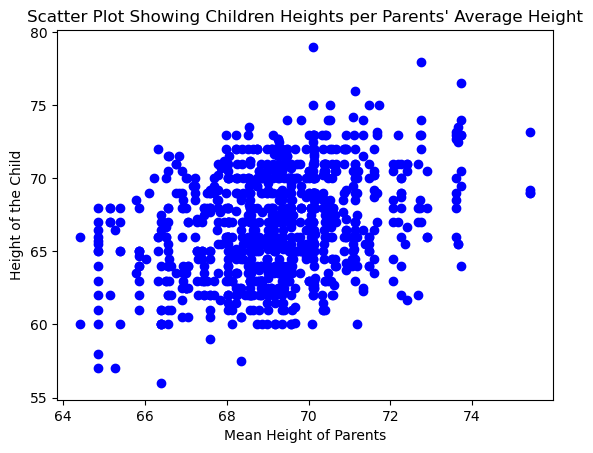

In [29]:
# YOUR CODE HERE
x = heights['midparentHeight']
y = heights['childHeight']

#essential for the part after question 1.3
midparentHeight = x
child = y

plt.scatter(x, y, c='b',label="Actual Childrens' Height")
plt.xlabel('Mean Height of Parents')
plt.ylabel('Height of the Child')
plt.title("Scatter Plot Showing Children Heights per Parents' Average Height")
plt.legend
plt.show

The reason for studying this data is to be able to predict the adult height of a child born to parents who are similar to those in the dataset. Suppose there's a new couple that wants to predict their child's height. Let the average height of the couple be 70 inches. How would we make a reasonable prediction? </p>

One approach would be to make our prediction based on the parent average around a height of 70 inches, say within .5 inches. The prediction equals the average child's height calculated from those points alone.

**Question 1.3.** Take the parents who have heights between 69.5 and 70.5 inches (inclusive), and compute the average of their children's height. Round your answer to 4 decimal points.

In [9]:
# YOUR CODE HERE
heights_1 = heights[heights['midparentHeight'] >= 69.5]
heights_2 = heights_1[heights_1['midparentHeight'] <= 70.5]

childrens_height = 0
childH_arr = heights_2['childHeight'].values

for i in childH_arr:
    childrens_height += i

close_to_70 = float(np.round((childrens_height/(len(heights_2))), 4))
close_to_70

67.2729

In [38]:
# TEST CELL: do not delete!

Run the cell below. The red lines show us the data points considered in our calculation above. The gold point represents our predicted child height based on the parent's height.

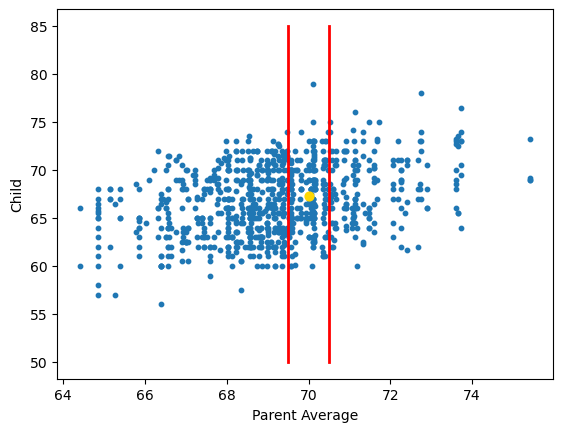

In [10]:
plt.scatter(midparentHeight, child, s = 10)
plt.xlabel('Parent Average')
plt.ylabel('Child')

plt.plot([69.5, 69.5], [50, 85], color='red', lw=2)  # plots red vertical lines
plt.plot([70.5, 70.5], [50, 85], color='red', lw=2)
plt.scatter(70, close_to_70, color='gold', s=40);  # plots gold point

Instead of repeating these steps for each point we'd like to predict, we can implement a function instead!

**Question 1.4.** Implement a function called `predict_child` whose only argument is the average height of the parents. The function should return the predicted height of the child, rounded to four decimal points.

In [30]:
# YOUR CODE HERE
def predict_child(avg_parents):
    heights_1 = heights[heights['midparentHeight'] >= (avg_parents-0.5)]
    heights_2 = heights_1[heights_1['midparentHeight'] <= (avg_parents+0.5)]

    childrens_height = 0
    childH_arr = heights_2['childHeight'].values

    for i in childH_arr:
        childrens_height += i

    close_to_avg_parents = float(np.round((childrens_height/(len(heights_2))), 4))
    return close_to_avg_parents

In [31]:
# TEST CELL: do not delete!
### VISIBLE TESTS
assert(predict_child(70) == 67.2729)

We can get a sense of how good our predictions are by comparing the predictions with the data we already have. Let's use our function defined above to calculate the predicted child height of each average couple height.

**Question 1.5.** Write a `for` loop that goes through each average parent height in `heights` and uses the `predict_child` function to calculate the child's height. Append each answer to the array `child_predictions`.

In [32]:
child_predictions = []

# YOUR CODE HERE
parents_avg = heights['midparentHeight'].values
j = 0
for i in parents_avg:
    child_predictions.append(predict_child(i))

# the code below makes a copy of heights and inserts the Predictions column
height_and_prediction = heights.copy()
height_and_prediction.insert(8, "Predictions", child_predictions, True)
height_and_prediction

,family,father,mother,midparentHeight,children,childNum,sex,childHeight,Predictions
0,1,78.5,67.0,75.43,4,1,male,73.2,70.1000
1,1,78.5,67.0,75.43,4,2,female,69.2,70.1000
2,1,78.5,67.0,75.43,4,3,female,69.0,70.1000
3,1,78.5,67.0,75.43,4,4,female,69.0,70.1000
4,2,75.5,66.5,73.66,4,1,male,73.5,70.4158
...,...,...,...,...,...,...,...,...,...
929,203,62.0,66.0,66.64,3,1,male,64.0,65.1566
930,203,62.0,66.0,66.64,3,2,female,62.0,65.1566
931,203,62.0,66.0,66.64,3,3,female,61.0,65.1566
932,204,62.5,63.0,65.27,2,1,male,66.5,64.2296


In [43]:
# TEST CELL: do not delete!

To compare two sets of data, we can scatter two plots on the same set of axes *as long as the x-axis is the same for both datasets*.

**Question 1.6.** Scatter the parent average data like you did above, then plot the `Predictions` data that you found by overlaying it on the same plot. Before plotting, make sure that both x-axes are the same for the two sets of data and include appropriate axis labels and a legend!

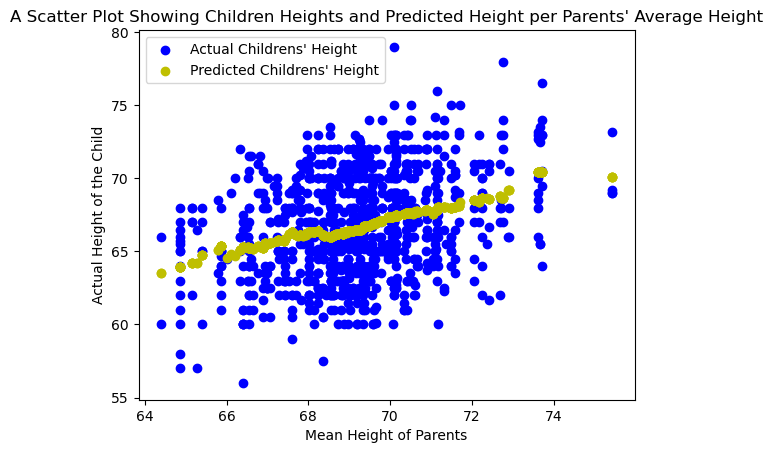

In [34]:
# YOUR CODE HERE
x = heights['midparentHeight']
y = heights['childHeight']
y2 = child_predictions

plt.scatter(x, y, c='b', label="Actual Childrens' Height")
plt.scatter(x, y2, c='y', label="Predicted Childrens' Height")
plt.xlabel('Mean Height of Parents')
plt.ylabel('Actual Height of the Child')
plt.title("A Scatter Plot Showing Children Heights and Predicted Height per Parents' Average Height")
plt.legend()
plt.show()

The graph of predictions is called a *graph of averages* because each dot is the average of a vertical strip (like we did in question 1.3.). Notice how the graph of averages roughly follows a straight line. This line is called the *regression line* and is a common method for making predictions.

# 2. Regression Models

You may recall from your stats classes the correlation coefficient, $r$, and how it's used to quantify the linear relationship between two variables. It turns out that  $r$ also helps us identify the straight line about which our datapoints are clustered, making useful for linear regression models.

**Question 2.1.** Use the `corrcoef` function to calculate the correlation coefficient between the predicted data above and the average parent height. Assign your answer to the name `correlation_coefficient`. (**Note**: The `corrcoef` function is part of the `numpy` library.)

In [35]:
# YOUR CODE HERE
correlation_coefficient_1= np.corrcoef(child_predictions, heights['midparentHeight'])
correlation_coefficient = float(correlation_coefficient_1[0][1])
correlation_coefficient

0.9732141181326853

In [46]:
# TEST CELL: do not delete!

## Standard Units

Notice that when we calculate $r$, it doesn't use any units. This is because $r$ is based on *standard units*. Standard units (**SU**) are calculated by converting each original data point ($X$) by subtracting the mean ($μ$) from it and then dividing the result by the standard deviation ($σ$): $$Z = \frac{X - \mu}{\sigma}$$

**Question 2.2.** Create a function that converts an array of numbers to standard units. The function takes one argument which is the original array and returns the converted array. Then, create a new DataFrame that contains the converted data with the columns `MidParent SU` and `Child SU`.   Assign your new DataFrame to `heights_SU`.

In [36]:
# YOUR CODE HERE
def stdunits(arr):
    #Start first by finding the mean
    total_arr = 0
    for i in arr:
        total_arr += i
    mean_arr = total_arr/(len(arr))

    #Then we can find the standard deviation
    total2_arr = 0
    for i in arr:
        total2_arr += (i - mean_arr)**2
    std_dev = np.sqrt(total2_arr/(len(arr)))

    #Now I can convert to standard units
    #make a new array
    conv_arr = []
    for i in arr:
        conv_arr.append((i-mean_arr)/std_dev)
    return conv_arr

midparents_arr = heights['midparentHeight'].values
midp_convArr = stdunits(midparents_arr)

childheight_arr = heights['childHeight'].values
childh_convArr = stdunits(childheight_arr)

heights_SU = pd.DataFrame({'MidParent SU':midp_convArr, 'Child SU':childh_convArr})


heights_SU

,MidParent SU,Child SU
0,3.454652,1.804156
1,3.454652,0.686005
2,3.454652,0.630097
3,3.454652,0.630097
4,2.472085,1.888017
...,...,...
929,-1.424873,-0.767591
930,-1.424873,-1.326667
931,-1.424873,-1.606205
932,-2.185390,-0.068747


In [ ]:
# TEST CELL: do not delete!

On this scale, we can calculate our predictions exactly as before. But first we have to figure out how to convert our old definition of “close” points to a value on the new scale. We had said that midparent heights were “close” if they were within 0.5 inches of each other. Since standard units measure distances in units of Standard Deviation (SDs), we have to figure out how many SDs of midparent height correspond to 0.5 inches.

**Question 2.3.** Calculate how many inches **one** SD of midparent heights is. How many SDs would 0.5 inches be? Assign your answers to `sd_midparent` and `close` respectively.

In [37]:
# YOUR CODE HERE
#Reusing the code from the previous question
#Start first by finding the mean
total_arr = 0
for i in heights['midparentHeight']:
    total_arr += i
mean_arr = total_arr/(len(heights))

#Then we can find the standard deviation
total2_arr = 0
for i in heights['midparentHeight']:
    total2_arr += (i - mean_arr)**2
sd_midparent = float(np.sqrt(total2_arr/(len(heights))))
close = 0.5/sd_midparent

In [ ]:
# TEST CELL: do not delete!

**Question 2.4.** Now, make a function that predicts a child's height in standard units based on their midparent height in standard units. The function should take one argument: the midparent height in standard units. Use the same logic as in Question 1.4, but instead of subtracting and adding 0.5, use your `close` variable that you defined above. Name your function `predict_child_SU` and round your answer to 4 decimal points.

In [38]:
# YOUR CODE HERE
def predict_child_SU(avg_parents):
    heights_1 = heights_SU[heights_SU['MidParent SU'] >= (avg_parents-close)]
    heights_2 = heights_1[heights_1['MidParent SU'] <= (avg_parents+close)]

    childrens_height = 0
    childH_arr = heights_2['Child SU'].values

    for i in childH_arr:
        childrens_height += i

    close_to_avg_parents = float(np.round((childrens_height/(len(heights_2))), 4))
    return close_to_avg_parents

Write a for loop that iterates through all of `MidParent SU` and uses `predict_child_SU` to predict the child's SU. Append your answers to `child_predictions_SU`.

In [39]:
child_predictions_SU = []

# YOUR CODE HERE
j = 0
for i in midp_convArr:
    child_predictions_SU.append(predict_child_SU(i))
# the code below makes a copy of heights_SU and inserts the Predictions SU column
height_and_prediction_SU = heights_SU.copy()
height_and_prediction_SU.insert(2, "Predictions SU", child_predictions_SU, True)
height_and_prediction_SU

,MidParent SU,Child SU,Predictions SU
0,3.454652,1.804156,0.9376
1,3.454652,0.686005,0.9376
2,3.454652,0.630097,0.9376
3,3.454652,0.630097,0.9376
4,2.472085,1.888017,1.0259
...,...,...,...
929,-1.424873,-0.767591,-0.4443
930,-1.424873,-1.326667,-0.4443
931,-1.424873,-1.606205,-0.4443
932,-2.185390,-0.068747,-0.7034


In [40]:
# TEST CELL: do not delete!

**Question 2.5.** Now make a scatter plot of the SU child data and the SU prediction data (similar to how you did in question 1.6.). Ensure the plot has appropriate axis labels and a legend.

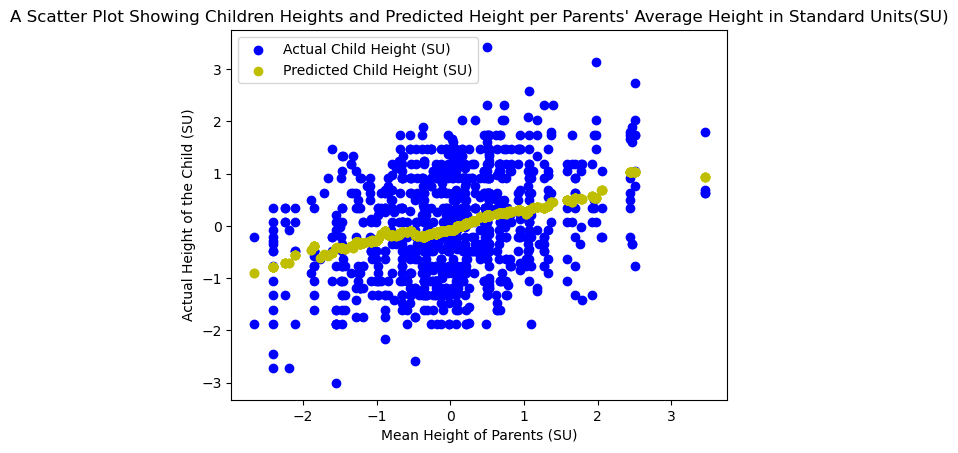

In [41]:
# YOUR CODE HERE
x = heights_SU['MidParent SU']
y = heights_SU['Child SU']
y2 = child_predictions_SU

plt.scatter(x, y, c='b', label='Actual Child Height (SU)')
plt.scatter(x, y2, c='y', label='Predicted Child Height (SU)')
plt.xlabel('Mean Height of Parents (SU)')
plt.ylabel('Actual Height of the Child (SU)')
plt.title("A Scatter Plot Showing Children Heights and Predicted Height per Parents' Average Height in Standard Units(SU)")

plt.legend()
plt.show()

Notice how the plotted SU data is the exact same as the original data, only the axes are different. This confirms that we can understand the prediction process using standard units.

# 3. The Regression Line

In regression, we use the value of one variable, $x$, (our predictor, e.g., midparentHeight) to predict the value of another, $y$, (our response, e.g., childHeight). The regression line provides the best linear fit for this prediction.

When variables are in original units, the equation of the regression line for predicting $y$ based on $x$ is:

$y$ = $intercept$ + $slope$ $*$ $x$.


The **slope** of this line is:$$r * \frac{SD_y}{SD_x}$$

Furthermore, the regression line passes through the **point of averages** $(\bar{x}, \bar{y})$, where $\bar{x}$ is the mean of $x$ and $\bar{y}$ is the mean of $y$. This fact is used to derive the **y-intercept**:

$$\text{intercept} = \bar{y} - \text{slope} * \bar{x}$$



**Question 3.1.** Write two functions called `slope` and `intercept` that use the equations above. Both functions should take three arguments: a Dataframe, the name of the predictor column `x` (e.g., 'midparentHeight'), and the name of the response `y` (e.g., 'childHeight'). The `slope` function should return the calculated slope, and the `intercept` function should return the calculated y-intercept.

In [42]:
# YOUR CODE HERE
def slope(datafm, x, y):
    #First get the array of values
    col_x = datafm[x].values
    col_y = datafm[y].values
    correlation_coefficient_1 = np.corrcoef(col_x, col_y)
    correlation_coefficient = float(correlation_coefficient_1[0][1])

    #Reusing the code again for calculating mean and standard deviation
    #mean and std deviation for x
    total_arr = 0
    for i in col_x:
        total_arr += i
    mean_arr_x = total_arr/(len(col_x))

    #Then we can find the standard deviation
    total2_arr = 0
    for i in col_x:
        total2_arr += (i - mean_arr_x)**2
    sd_x = float(np.sqrt(total2_arr/(len(col_x))))

    #mean and std deviation for y
    total_arr_2 = 0
    for i in col_y:
        total_arr_2 += i
    mean_arr_y = total_arr_2/(len(col_y))

    #Then we can find the standard deviation
    total2_arr_2 = 0
    for i in col_y:
        total2_arr_2 += (i - mean_arr_y)**2
    sd_y = float(np.sqrt(total2_arr_2/(len(col_y))))

    slope_var = correlation_coefficient * (sd_y/sd_x)
    return slope_var

    

def intercept(datafm, x, y):
    #First get the slope and the array of values
    slope_var = slope(datafm, x, y)
    col_x = datafm[x].values
    col_y = datafm[y].values

    #mean for x
    total1 = 0
    for i in col_x:
        total1 += i
    mean_arr_x = total1/(len(col_x))
    
    #mean for y
    total2 = 0
    for i in col_y:
        total2 += i
    mean_arr_y = total2/(len(col_y))

    intercept_var = float((mean_arr_y) - (slope_var*mean_arr_x)) 
    return intercept_var

In [43]:
#run this cell
family_slope = slope(heights, 'midparentHeight', 'childHeight')
family_intercept = intercept(heights, 'midparentHeight', 'childHeight')
family_slope, family_intercept

(0.6373608969694787, 22.636240549589743)

In [44]:
# TEST CELL: do not delete!

The equation for the regression line is shown below:

$$estimate\:of\:child's\:height = 0.64 * midParent\:height + 22.64$$ For example, for a midparent height of 70.48 inches, the regression equation predicts the child’s height to be 67.56 inches.

In [45]:
family_slope * 70.48 + family_intercept

67.55743656799861

**Question 3.2.** Write a function called `reg_prediction` that takes in one argument as the parent height average and returns the regression equation that predicts the child's height. Then, use that function and a for loop to calculate the regression predictions. Append your answers to `regression_predictions`.

In [46]:
# YOUR CODE HERE
def reg_prediction(parent_avg):
    return (((slope(heights, 'midparentHeight', 'childHeight')) * parent_avg) + (intercept(heights, 'midparentHeight', 'childHeight')))

In [47]:
regression_predictions = []

# YOUR CODE HERE
for i in heights['midparentHeight']:
    regression_predictions.append(reg_prediction(i))
# the code below makes a copy of heights and inserts the Predictions column
height_and_prediction.insert(9, "Regression Predictions", regression_predictions, True)
height_and_prediction

,family,father,mother,midparentHeight,children,childNum,sex,childHeight,Predictions,Regression Predictions
0,1,78.5,67.0,75.43,4,1,male,73.2,70.1000,70.712373
1,1,78.5,67.0,75.43,4,2,female,69.2,70.1000,70.712373
2,1,78.5,67.0,75.43,4,3,female,69.0,70.1000,70.712373
3,1,78.5,67.0,75.43,4,4,female,69.0,70.1000,70.712373
4,2,75.5,66.5,73.66,4,1,male,73.5,70.4158,69.584244
...,...,...,...,...,...,...,...,...,...,...
929,203,62.0,66.0,66.64,3,1,male,64.0,65.1566,65.109971
930,203,62.0,66.0,66.64,3,2,female,62.0,65.1566,65.109971
931,203,62.0,66.0,66.64,3,3,female,61.0,65.1566,65.109971
932,204,62.5,63.0,65.27,2,1,male,66.5,64.2296,64.236786


In [48]:
# TEST CELL: do not delete!

**Question 3.3.** Now, make a scatter plot that includes the **original child height data**, **the predicted data** (from Section 1), and newly calculated **regression prediction data**. Ensure the plot has appropriate axis labels and a legend to distinguish the three sets of points.

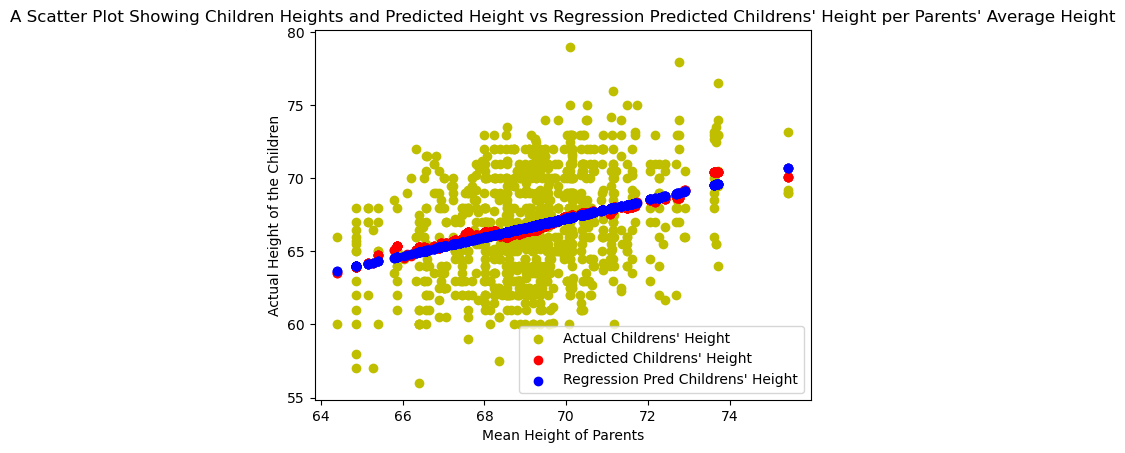

In [28]:
# YOUR CODE HERE
x = heights['midparentHeight']
y = heights['childHeight']
y2 = child_predictions
y3 = regression_predictions

plt.scatter(x, y, c='y', label="Actual Childrens' Height")
plt.scatter(x, y2, c='r', label="Predicted Childrens' Height")
plt.scatter(x, y3, c='b', label="Regression Pred Childrens' Height")
plt.xlabel('Mean Height of Parents')
plt.ylabel('Actual Height of the Children')
plt.title("A Scatter Plot Showing Children Heights and Predicted Height vs Regression Predicted Childrens' Height per Parents' Average Height")

plt.legend()
plt.show()

# Rubric

| Question | Points|
|----------|----------|
| 1.1.   | 2   |
| 1.2.    | 10   |
| 1.3.    | 10   |
| 1.4.   | 10   |
| 1.5.    | 5  |
| 1.6.   | 12   |
| 2.1.    |5  |
| 2.2.   | 10   |
| 2.3.   | 4   |
| 2.4.    | 10  |
| 2.5.   | 12   |
| 3.1.    | 6  |
| 3.2.   | 10   |
| 3.3.  | 10   |    
| Total:    | 116   |


family_heights: data8